In [13]:
import pandas as pd
import numpy as np 

In [14]:
# dengesiz veri setiyle ugraşıcaz düzeltmeye ugraşıcaz

In [15]:
# random seed

np.random.seed(42)

set1no = 900
set2no = 100

In [18]:
df1 = pd.DataFrame({
    "feature_1" : np.random.normal(loc = 0, scale = 1, size = set1no),
    "feature_2" : np.random.normal(loc = 0, scale = 1, size = set1no),
    "target" : [0] * set1no
})

df2 = pd.DataFrame({
    "feature_1" : np.random.normal(loc = 0, scale = 1, size = set2no),
    "feature_2" : np.random.normal(loc = 0, scale = 1, size = set2no),
    "target" : [1] * set2no
})

In [19]:
df1.head()

,feature_1,feature_2,target
0,0.368673,1.901191,0
1,-0.393339,-0.060661,0
2,0.028745,-0.708407,0
3,1.278452,-1.513714,0
4,0.191099,-1.803140,0


In [20]:
df2.head()

,feature_1,feature_2,target
0,0.386809,0.183835,1
1,1.090980,2.693034,1
2,2.012270,0.349800,1
3,1.023710,-1.004055,1
4,0.249309,-0.095464,1


In [24]:
df = pd.concat([df1,df2]).reset_index(drop=True) # dataframeleri yada serileri birleştirmeye yarar

In [25]:
df

,feature_1,feature_2,target
0,0.368673,1.901191,0
1,-0.393339,-0.060661,0
2,0.028745,-0.708407,0
3,1.278452,-1.513714,0
4,0.191099,-1.803140,0
...,...,...,...
995,-0.848429,3.926238,1
996,0.573128,-2.084113,1
997,-1.785866,1.724697,1
998,-0.359630,-0.287448,1


In [26]:
df["target"].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [27]:
df["target"].unique()

array([0, 1])

In [28]:
# verimizde 0 lardan 900 tane ve 1 leren 100 tane vardır bu da bizim için dengesiz bir veri seti oluşturuyor
# bundan dolayı bunu düzeltmeini 2 yolu vardır

In [29]:
#1  upsampling -> upsample minority ( az olanı artırmak ) 
#2 downsampling -> downsample majority ( çok olanı azaltma )

In [30]:
# eger datamızda veri az ise genelde upsampling tercih ederiz normalde de genelde upsampling tercih ederiz 

In [31]:
# UPSAMPLING

In [32]:
df_minority = df[df["target"] == 1 ]

In [33]:
df_minority

,feature_1,feature_2,target
900,0.386809,0.183835,1
901,1.090980,2.693034,1
902,2.012270,0.349800,1
903,1.023710,-1.004055,1
904,0.249309,-0.095464,1
...,...,...,...
995,-0.848429,3.926238,1
996,0.573128,-2.084113,1
997,-1.785866,1.724697,1
998,-0.359630,-0.287448,1


In [34]:
df_majority = df[df["target"] == 0 ] 

In [35]:
df_majority 

,feature_1,feature_2,target
0,0.368673,1.901191,0
1,-0.393339,-0.060661,0
2,0.028745,-0.708407,0
3,1.278452,-1.513714,0
4,0.191099,-1.803140,0
...,...,...,...
895,-0.751969,1.431367,0
896,-0.319054,1.081767,0
897,-0.796026,-1.312219,0
898,1.076007,0.622070,0


In [37]:
from sklearn.utils import resample #downsampling yada upsampling için kullanacagımız kütüphanemiz 

In [39]:
df_minority_upsample = resample(df_minority,replace = True ,n_samples=len(df_majority),random_state=42)

In [40]:
df_minority_upsample 

,feature_1,feature_2,target
951,1.573020,0.833334,1
992,-0.412998,0.768207,1
914,0.367649,1.832557,1
971,-0.746578,0.458387,1
960,0.629530,-0.531214,1
...,...,...,...
952,-0.465806,-1.104863,1
965,0.820344,-0.307808,1
976,-0.256180,-0.936506,1
942,0.043515,1.476934,1


In [43]:
df_minority_upsample.head()

,feature_1,feature_2,target
951,1.573020,0.833334,1
992,-0.412998,0.768207,1
914,0.367649,1.832557,1
971,-0.746578,0.458387,1
960,0.629530,-0.531214,1


In [45]:
df_upsampled = pd.concat([df_majority,df_minority_upsample])

In [48]:
df_upsampled # iki verimizi birleştirdik

,feature_1,feature_2,target
0,0.368673,1.901191,0
1,-0.393339,-0.060661,0
2,0.028745,-0.708407,0
3,1.278452,-1.513714,0
4,0.191099,-1.803140,0
...,...,...,...
952,-0.465806,-1.104863,1
965,0.820344,-0.307808,1
976,-0.256180,-0.936506,1
942,0.043515,1.476934,1


In [49]:
df_upsampled["target"].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [50]:
# artık verimizdeki degerler 900 e 900 oldu daha dengeli bir hale getirdik verimizi

In [51]:
df_majority_downsample =  resample(df_majority,replace=True,n_samples=len(df_minority),random_state = 42)

In [53]:
df_majority_downsample

,feature_1,feature_2,target
102,0.059630,1.173125,0
435,-0.337086,0.730764,0
860,1.639965,-1.175595,0
270,0.758929,0.965397,0
106,0.895193,-1.570876,0
...,...,...,...
201,-2.896255,-0.144519,0
269,0.853416,0.926215,0
862,0.075434,0.597228,0
815,-0.090533,0.668340,0


In [54]:
df_majority_downsample["target"].value_counts()

target
0    100
Name: count, dtype: int64

In [55]:
df_downsample = pd.concat([df_majority_downsample,df_minority])

In [57]:
df_downsample

,feature_1,feature_2,target
102,0.059630,1.173125,0
435,-0.337086,0.730764,0
860,1.639965,-1.175595,0
270,0.758929,0.965397,0
106,0.895193,-1.570876,0
...,...,...,...
995,-0.848429,3.926238,1
996,0.573128,-2.084113,1
997,-1.785866,1.724697,1
998,-0.359630,-0.287448,1


In [58]:
# 200 satırımız oldu bu seferde 100 e 100 şeklinde bir tablo oluşturduk kendimize

In [60]:
df_downsample["target"].value_counts()

target
0    100
1    100
Name: count, dtype: int64

In [61]:
# burada datayaa direkt tekrar eden veriyi ekledik bunun yerine benzer veriyee ekleyebiliriz ve daha iyi bir data elde etmiş oluruz 

In [62]:
# SMOTE (YUKARIDA Kİ ŞEY )

In [63]:
df

,feature_1,feature_2,target
0,0.368673,1.901191,0
1,-0.393339,-0.060661,0
2,0.028745,-0.708407,0
3,1.278452,-1.513714,0
4,0.191099,-1.803140,0
...,...,...,...
995,-0.848429,3.926238,1
996,0.573128,-2.084113,1
997,-1.785866,1.724697,1
998,-0.359630,-0.287448,1


In [64]:
import matplotlib.pyplot as plt

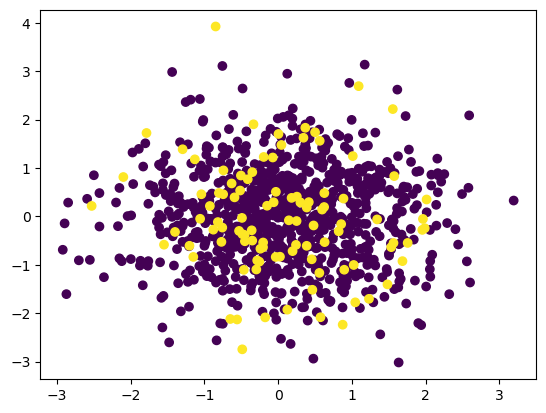

In [66]:
plt.scatter(df["feature_1"],df["feature_2"],c=df["target"])

In [69]:
! pip install imblearn 

In [70]:
# sıfırdan kod yazmak yerine bunu kullanırız

In [71]:
from imblearn.over_sampling import SMOTE

In [72]:
oversample = SMOTE()

In [74]:
(X , y) = oversample.fit_resample(df[["feature_1","feature_2"]],df["target"])

In [75]:
X

,feature_1,feature_2
0,0.368673,1.901191
1,-0.393339,-0.060661
2,0.028745,-0.708407
3,1.278452,-1.513714
4,0.191099,-1.803140
...,...,...
1795,-0.242993,-0.676121
1796,0.057074,0.336122
1797,0.897661,2.417486
1798,-0.690545,0.476995


In [76]:
type(X)

pandas.core.frame.DataFrame

In [79]:
oversample_df = pd.concat([X,y] , axis=1)

In [80]:
oversample_df

,feature_1,feature_2,target
0,0.368673,1.901191,0
1,-0.393339,-0.060661,0
2,0.028745,-0.708407,0
3,1.278452,-1.513714,0
4,0.191099,-1.803140,0
...,...,...,...
1795,-0.242993,-0.676121,1
1796,0.057074,0.336122,1
1797,0.897661,2.417486,1
1798,-0.690545,0.476995,1


In [82]:
oversample_df["target"].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [83]:
# verimzi gene 900 e 900 şeklinde doldurduk

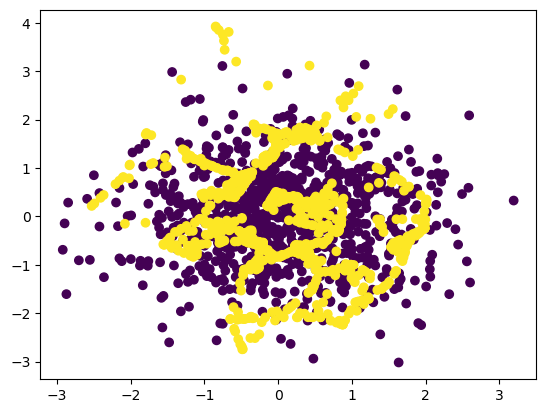

In [85]:
plt.scatter(oversample_df["feature_1"],oversample_df["feature_2"],c=oversample_df["target"])

In [97]:
# ENCODING

In [109]:
### 📊 Kategori Kodlama (Encoding) Teknikleri Özet Tablosu

 # | Kodlama Tekniği (Encoding) | Ne İşe Yarar? | Ne Zaman Kullanılır? (Use Case) | Avantaj / Dezavantaj |
 # :---: | :--- | :--- | :--- | :--- |
  #**1** | **One-Hot Encoding** | Her eşsiz kategoriyi `0` veya `1` içeren ayrı birer sütuna dönüştürür. | Sıralama önemsiz (**Nominal**) ve az sayıda eşsiz kategori olduğunda (Örn: Renkler, Ülkeler). | 🟢 Yapay zeka modellerine büyüklük/küçüklük algısı dayatmaz.<br>🔴 Çok fazla kategori varsa sütun sayısı patlar (Kürlet laneti). |
  #**2** | **Label Encoding** | Her kategoriye `0, 1, 2...` gibi sıralı benzersiz bir tam sayı (integer) atar. | Kategoriler arasında doğal bir sıralama (**Ordinal**) olduğunda (Örn: Small, Medium, Large). | 🟢 Çok hızlı ve hafıza dostudur.<br>🔴 Sıralama önemsiz verilerde modele "Yüksek değer alan daha üstündür" gibi yanlış bir mesaj verebilir. |
  #**3** | **Ordinal Encoding** | Label encoding gibidir ama hangi kategorinin hangi sayıyı alacağını **manuel (elle)** belirlememizi sağlar. | Kategorilerin hiyerarşik sıralaması kesin ve önemli olduğunda (Örn: Eğitim Durumu: Lise=1, Lisans=2, Yüksek Lisans=3). | 🟢 Mantıksal hiyerarşiyi (büyüklük sırasını) korur.<br>🔴 Doğru sıralama elle girilmezse verinin yapısı bozulabilir. |
  #**4** | **Frequency Encoding** | Kategorileri, o kategorinin veri setinde kaç kez geçtiği frekans (count) değeriyle değiştirir. | Çok fazla eşsiz kategoriye (**High-Cardinality**) sahip değişkenlerde (Örn: Şehirler, Posta Kodları). | 🟢 Sütun sayısını artırmadan verideki yoğunluk bilgisini modele aktarır.<br>🔴 Farklı iki kategori aynı frekansa sahipse aynı sayıyı alırlar (Çakışma riski). |
  #**5** | **Target (Mean) Encoding** | Kategorileri, hedef değişkenin (Target) o kategoriye ait ortalaması (Mean) ile değiştirir. | Kategorik değişken ile tahmin edilmek istenen hedef arasında güçlü bir ilişki olduğunda. | 🟢 Modelin tahmin başarısını ciddi şekilde artırabilir.<br>🔴 **Overfitting** (aşırı öğrenme) riski çok yüksektir, cross-validation ile dikkatli kullanılmalıdır. |
  #**6** | **Binary Encoding** | Kategorileri önce sayılara, sonra o sayıları ikilik (binary) tabana çevirerek ayrı sütunlara dağıtır. | Sütun sayısını çok fazla artırmadan, yüksek sayıda kategoriyi (**High-Cardinality**) belleği yormadan kodlamak istendiğinde. | 🟢 One-Hot Encoding'e göre çok daha az sütun üretir (Hafıza dostudur).<br>🔴 Modeller için yorumlanabilirliği biraz daha karmaşıktır. |

In [98]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [99]:
df = sns.load_dataset("titanic")

In [100]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [101]:
# buradaki asıl amacımız kadagorik verleri numeric veriye geçirmeye çalışıyoruz

In [102]:
df[["sex","class","embark_town"]].isna().sum()

sex            0
class          0
embark_town    2
dtype: int64

In [103]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [104]:
df = df.dropna(subset=["embark_town"])

In [105]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [107]:
df[["sex","class","embark_town"]].isna().sum()

sex            0
class          0
embark_town    0
dtype: int64

In [113]:
# ONE HOT ENCODING

In [110]:
df["sex"].value_counts()

sex
male      577
female    312
Name: count, dtype: int64

In [111]:
df["class"].value_counts()

class
Third     491
First     214
Second    184
Name: count, dtype: int64

In [112]:
df["embark_town"].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [121]:
df_onehot = pd.get_dummies(df,columns=["sex","embark_town"],drop_first=True)

In [122]:
df_onehot

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,alive,alone,sex_male,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,S,Third,man,True,NaN,no,False,True,False,True
1,1,1,38.0,1,0,71.2833,C,First,woman,False,C,yes,False,False,False,False
2,1,3,26.0,0,0,7.9250,S,Third,woman,False,NaN,yes,True,False,False,True
3,1,1,35.0,1,0,53.1000,S,First,woman,False,C,yes,False,False,False,True
4,0,3,35.0,0,0,8.0500,S,Third,man,True,NaN,no,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,Second,man,True,NaN,no,True,True,False,True
887,1,1,19.0,0,0,30.0000,S,First,woman,False,B,yes,True,False,False,True
888,0,3,NaN,1,2,23.4500,S,Third,woman,False,NaN,no,False,False,False,True
889,1,1,26.0,0,0,30.0000,C,First,man,True,C,yes,True,True,False,False


In [123]:
df_onehot.columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'embarked',
       'class', 'who', 'adult_male', 'deck', 'alive', 'alone', 'sex_male',
       'embark_town_Queenstown', 'embark_town_Southampton'],
      dtype='object')

In [126]:
# sex ve embark_town kolanları gitmiş ama onlara gerek yok ornegin sex male kısmı true ıse erkek folse ise kız 
# qustown true ise ordan binmiştir embark true ise ordan binmiştir ikiside folse ise southemptndan binmiştir
#böylece tablomuzuda küçültmüş olduk

In [127]:
# LABEL ENCODER

In [128]:
label_encoder =LabelEncoder()

In [129]:
df_label = df.copy()

In [130]:
df_label

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [131]:
# cinsiyeti 1 ve 0 çevrmeyi çalışalım 

In [133]:
df_label["sex"] = label_encoder.fit_transform(df_label["sex"])

In [135]:
df_label

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,0,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,0,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,1,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [136]:
# sex kısmı 0 ve 1 şeklinde degiştirmiştik olduk verimizde 

In [137]:
#ORDİNAL ENCODİNG

In [138]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [139]:
df_ordinal = df.copy()

In [140]:
ordinal_encoder = OrdinalEncoder() #hangi sırada olucagını biz belirlioruz yani order biz seçiyoruz 

In [141]:
# kategorikleri en başta vermek bu veridde daha mantıklıdır 

In [145]:
class_order = ["Third","Second","First"]

In [146]:
ordinal_encoder = OrdinalEncoder(categories=[class_order])

In [148]:
df_ordinal["class"] = ordinal_encoder.fit_transform(df_ordinal[["class"]])

In [149]:
df_ordinal

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,0.0,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,2.0,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,0.0,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,2.0,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,0.0,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1.0,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,2.0,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,0.0,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,2.0,man,True,C,Cherbourg,yes,True


In [150]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [151]:
# görüldügü üzeri third second ve first kısmını bir nevi puan atadık en iyi olana 2 verdik en kötü olana 0 verdik 

<Axes: title={'center': 'originall categorical'}, xlabel='sex'>

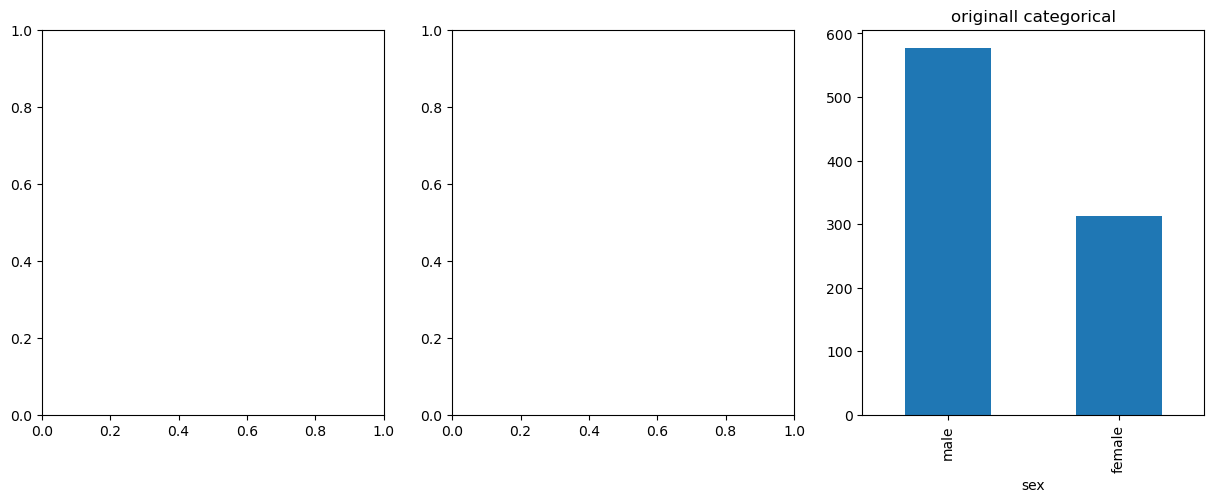

In [154]:
fig , axes = plt.subplots(1,3,figsize=(15,5))
df["sex"].value_counts().plot(kind="bar",title="originall categorical")

<Axes: title={'center': 'originall categorical'}, xlabel='sex'>

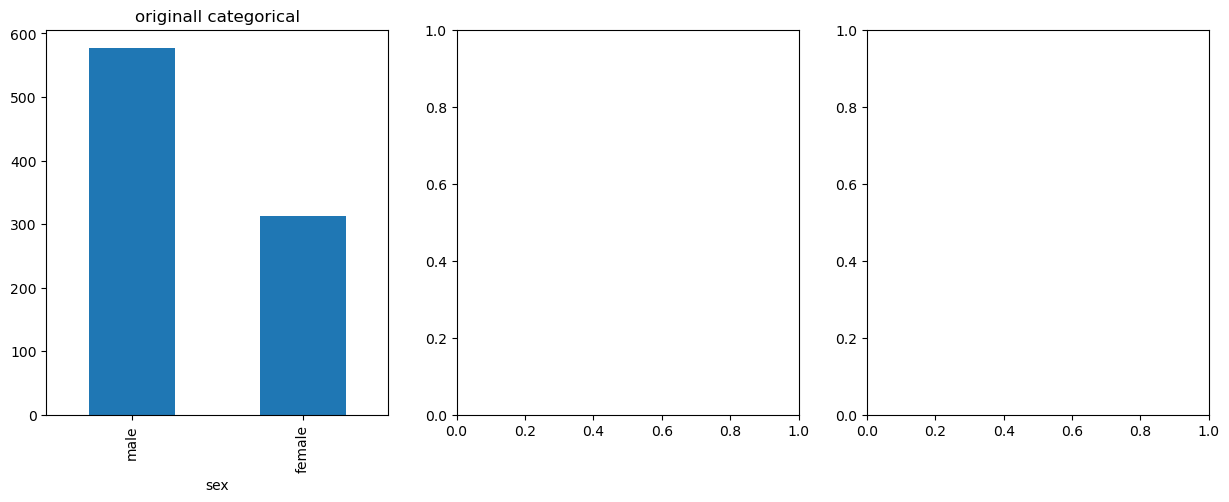

In [155]:
fig , axes = plt.subplots(1,3,figsize=(15,5))
df["sex"].value_counts().plot(kind="bar",ax=axes[0],title="originall categorical")

<Axes: title={'center': 'Label Encoded'}, xlabel='sex'>

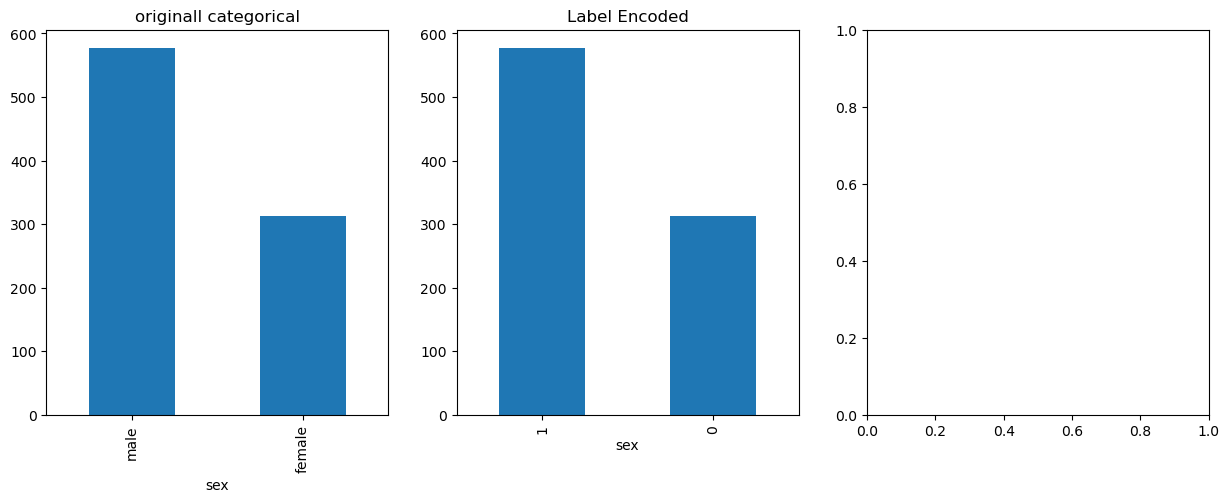

In [156]:
fig , axes = plt.subplots(1,3,figsize=(15,5))
df["sex"].value_counts().plot(kind="bar",ax=axes[0],title="originall categorical")
df_label["sex"].value_counts().plot(kind="bar",ax=axes[1],title="Label Encoded")

<Axes: title={'center': 'Onehot Encoded'}, xlabel='sex_male'>

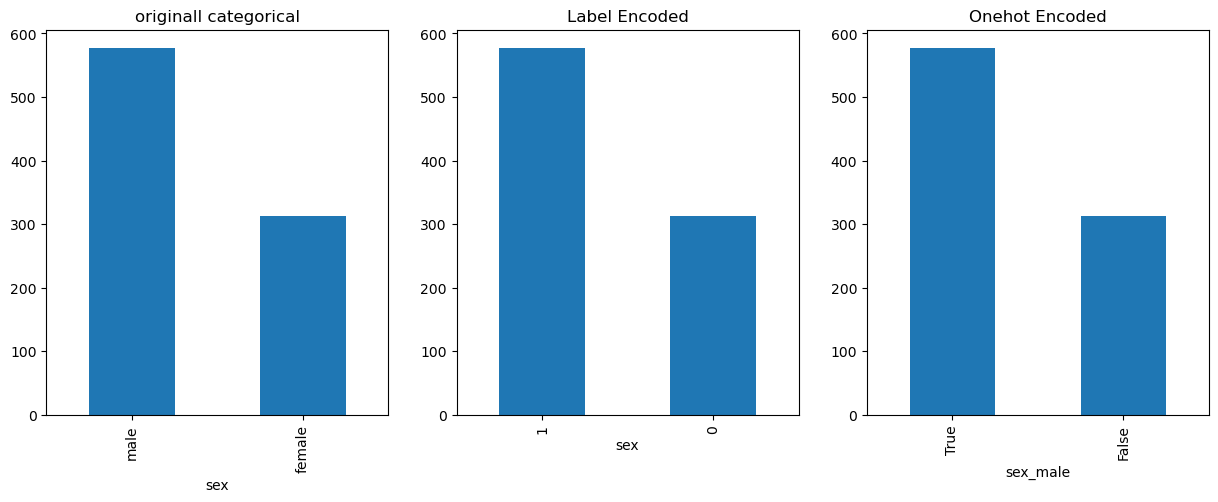

In [157]:
fig , axes = plt.subplots(1,3,figsize=(15,5))
df["sex"].value_counts().plot(kind="bar",ax=axes[0],title="originall categorical")
df_label["sex"].value_counts().plot(kind="bar",ax=axes[1],title="Label Encoded")
df_onehot["sex_male"].value_counts().plot(kind="bar",ax=axes[2],title="Onehot Encoded")

In [158]:
# görüldügü üzere degerler degişmiyor ama ona verdigimiz tanımla 0-1 male-female true-folse şeklinde oluyor